# Scaffold: CMS data and CKKW-L physics priors in vertical 3x1 panels

This notebook produces two vertical three-row, one-column mass-spectrum figures:

1. **CMS data** for the dimuon channels \(Z\), \(J/\psi\), and \(Y/\Upsilon\).
2. **Physics priors** (truth-level \(z\)-space) for the same three channels.

The priors are the **CKKW-L inclusive 0/1-jet** MG5+Pythia8 samples in
`data/`:

- Z: `cms_dymumu_mg5py8_ckkwl_8tev_inclusive_0j1j_fiducial_70_110_1M.hdf5`
- J/psi: `cms_jpsi_mumu_mg5py8_ckkwl_8tev_inclusive_0j1j_fiducial_3p0369_3p1569_1M_reweighted.hdf5`
- Upsilon/Y: `cms_upsilon_mumu_mg5py8_ckkwl_8tev_inclusive_0j1j_fiducial_8p5_11p5_1M.hdf5`

The notebook is written to run from the `scaffold/` directory and to locate
the repository root automatically.

In [2]:
# --- common setup ---------------------------------------------------------------
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

# Keep plots visible in the notebook.
%matplotlib inline

# notebook lives in <repo>/scaffold
NOTEBOOK_DIR = Path.cwd().resolve()
if (NOTEBOOK_DIR / "scaffold").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "scaffold"
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "scaffold" else NOTEBOOK_DIR
FIG_DIR = NOTEBOOK_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook dir:", NOTEBOOK_DIR.resolve())
print("Repo root:   ", REPO_ROOT.resolve())

Notebook dir: C:\Users\AhrixMarin\Desktop\otus\scaffold
Repo root:    C:\Users\AhrixMarin\Desktop\otus


In [3]:
# --- import shared invariant-mass helper (same stable convention as pipeline) ---
import sys
sys.path.insert(0, str(REPO_ROOT))

from scripts.physics import invariant_mass_np  # noqa: E402

MUON_MASS_GEV = 0.105658

def dilepton_mass(rows):
    # Stable massive-muon invariant mass for [N,8] p4 arrays.
    return invariant_mass_np(
        rows,
        daughter_masses=(MUON_MASS_GEV, MUON_MASS_GEV),
        stable=True,
    )

## 1. Resonance table and file locations

Each resonance has:
- its display label,
- the plotted mass window and bin count,
- the CKKW-L prior HDF5 path,
- the CMS selection used by the `cms_Joint` pipeline (Z and J/psi are read
  from existing selected region caches if available; otherwise they fall back
  to a chunked ROOT scan).

In [4]:
# The order here is also the vertical panel order (top to bottom: Z, J/psi, Y).
RESONANCES = {
    "z": {
        "name": "Z",
        "latex": r"$Z\to\mu^+\mu^-$",
        "reference_mass_gev": 91.1876,
        "mass_min_gev": 70.0,
        "mass_max_gev": 110.0,
        "n_bins": 80,
        "prior_file": (
            "cms_dymumu_mg5py8_ckkwl_8tev_inclusive_0j1j_"
            "fiducial_70_110_1M.hdf5"
        ),
        # Matches the data-side cms_Joint Z selection.
        "selection": {
            "muon_pt_min": 25.0,
            "muon_abs_eta_max": 2.4,
            "muon_pt_max": 100.0,
            "jpsi_mass_min": 70.0,
            "jpsi_mass_max": 110.0,
        },
    },
    "jpsi": {
        "name": "J/psi",
        "latex": r"$J/\psi\to\mu^+\mu^-$",
        "reference_mass_gev": 3.0969,
        "mass_min_gev": 3.0369,
        "mass_max_gev": 3.1569,
        "n_bins": 120,
        "prior_file": (
            "cms_jpsi_mumu_mg5py8_ckkwl_8tev_inclusive_0j1j_"
            "fiducial_3p0369_3p1569_1M_reweighted.hdf5"
        ),
        "selection": {
            "muon_pt_min": 3.0,
            "muon_abs_eta_max": 2.4,
            "muon_pt_max": 100.0,
            "jpsi_mass_min": 3.0369,
            "jpsi_mass_max": 3.1569,
        },
    },
    "y": {
        "name": "Y",
        "latex": r"$Y(1S,2S,3S)\to\mu^+\mu^-$",
        "reference_mass_gev": 9.4603,
        "mass_min_gev": 8.5,
        "mass_max_gev": 11.5,
        "n_bins": 150,
        "prior_file": (
            "cms_upsilon_mumu_mg5py8_ckkwl_8tev_inclusive_0j1j_"
            "fiducial_8p5_11p5_1M.hdf5"
        ),
        # The Y/upsilon CMS panel uses the small CMS Open Data outreach CSV,
        # not the reduced ROOT tree, to keep this scaffold light.
        "cms_csv": "experiments/cms_upsilon/data/Ymumu.csv",
    },
}

print(f"{'region':<6} {'mass window (GeV)':<24} {'bins':>4}  prior")
for key, info in RESONANCES.items():
    print(
        f"{key:<6} {info['mass_min_gev']:.4g}-{info['mass_max_gev']:.4g}"
        f"{'':<12} {info['n_bins']:>4}  {info['prior_file']}"
    )

region mass window (GeV)        bins  prior
z      70-110               80  cms_dymumu_mg5py8_ckkwl_8tev_inclusive_0j1j_fiducial_70_110_1M.hdf5
jpsi   3.037-3.157              120  cms_jpsi_mumu_mg5py8_ckkwl_8tev_inclusive_0j1j_fiducial_3p0369_3p1569_1M_reweighted.hdf5
y      8.5-11.5              150  cms_upsilon_mumu_mg5py8_ckkwl_8tev_inclusive_0j1j_fiducial_8p5_11p5_1M.hdf5


## 2. Load CMS data

For Z and J/psi the loader first looks for the full selected split cache under
`outputs/cms_Joint/.region_cache/<region>` whose metadata points to the CKKW-L
prior (the same CMS data used by the joint runs). If that cache is absent it
falls back to a chunked `uproot` scan of
`data/Run2012BC_DoubleMuParked_Muons.root`.

For Y/Upsilon it reads the small CMS Open Data `Ymumu.csv` sample and
reconstructs the invariant mass from the two muon four-vectors.

In [5]:
def _find_region_cache(region, prior_name):
    # Return the full (num_samples=None) cache npz path for a prior file.
    cache_dir = REPO_ROOT / "outputs" / "cms_Joint" / ".region_cache" / region
    if not cache_dir.is_dir():
        return None
    matches = []
    for json_path in sorted(cache_dir.glob("selected_split_*.json")):
        try:
            import json as json_module
            meta = json_module.loads(json_path.read_text(encoding="utf-8"))
        except Exception:
            continue
        prior_info = meta.get("theory_prior_file")
        prior_path = (
            prior_info.get("path", "") if isinstance(prior_info, dict) else str(prior_info)
        )
        if meta.get("num_samples") is not None:
            continue
        if Path(prior_path).name == prior_name or prior_name in str(prior_path):
            matches.append(json_path.with_suffix(".npz"))
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        # Prefer the newest cache when duplicates exist.
        return sorted(matches, key=lambda p: p.stat().st_mtime)[-1]
    return None


def load_cms_masses_from_npz(npz_path):
    # Compute masses without holding all p4 splits simultaneously.
    mass_parts = []
    with np.load(npz_path, allow_pickle=False) as cache:
        for key in ("x_train", "x_val", "x_test"):
            p4 = cache[key]
            mass_parts.append(dilepton_mass(np.asarray(p4, dtype=np.float64)))
            del p4
    return np.concatenate(mass_parts)


def load_cms_masses_from_root(info):
    # Fallback: use the same cms_data ROOT loader as the joint pipeline.
    from scripts.cms_data import load_cms_muon_x_data

    root_file = REPO_ROOT / "data" / "Run2012BC_DoubleMuParked_Muons.root"
    p4 = load_cms_muon_x_data(
        root_file,
        selection=info["selection"],
        step_size="100 MB",
    )
    return dilepton_mass(np.asarray(p4, dtype=np.float64))


def load_cms_masses(region, info):
    if region == "y":
        # CMS Y/Upsilon outreach CSV columns: E1,px1,py1,pz1,E2,px2,py2,pz2
        csv_path = REPO_ROOT / info["cms_csv"]
        data = np.genfromtxt(csv_path, delimiter=",", names=True, dtype=None, encoding=None)
        data = np.atleast_1d(data)
        names = {name.lower(): name for name in data.dtype.names}
        # Build the repo-convention [N,8] p4 array directly:
        # [mu1 px, mu1 py, mu1 pz, mu1 E, mu2 px, mu2 py, mu2 pz, mu2 E].
        p4 = np.column_stack(
            [
                data[names["px1"]], data[names["py1"]],
                data[names["pz1"]], data[names["e1"]],
                data[names["px2"]], data[names["py2"]],
                data[names["pz2"]], data[names["e2"]],
            ]
        ).astype(np.float64, copy=False)
        return dilepton_mass(np.asarray(p4, dtype=np.float64))

    cache = _find_region_cache(region, info["prior_file"])
    if cache is not None and cache.exists():
        masses = load_cms_masses_from_npz(cache)
        print(f"CMS {info['name']}: read selected cache {cache.name} ({len(masses):,} events)")
        return masses

    print(f"CMS {info['name']}: no full cache found; scanning CMS ROOT file (this can take a while)")
    return load_cms_masses_from_root(info)


CMS_MASSES = {}
for region, info in RESONANCES.items():
    m = load_cms_masses(region, info)
    keep = (m >= info["mass_min_gev"]) & (m <= info["mass_max_gev"])
    CMS_MASSES[region] = m[keep]
    print(f"  -> {info['name']}: {len(CMS_MASSES[region]):,} events in the plotted window")

CMS Z: read selected cache selected_split_aec522b7204a5843ba5f.npz (5,259,620 events)
  -> Z: 5,259,620 events in the plotted window
CMS J/psi: read selected cache selected_split_b65a524d4bd7d93a7f18.npz (3,624,454 events)
  -> J/psi: 3,624,450 events in the plotted window
  -> Y: 16,600 events in the plotted window


## 3. Load CKKW-L physics priors

Truth-level \(z\)-space rows are stored as
`[mu- px, mu- py, mu- pz, mu- E, mu+ px, mu+ py, mu+ pz, mu+ E]`.

In [6]:
def load_prior_masses(region, info):
    prior_path = REPO_ROOT / "data" / info["prior_file"]
    with h5py.File(prior_path, "r") as handle:
        z = np.asarray(handle["FDL/zData"], dtype=np.float64)
    masses = dilepton_mass(z)
    keep = (masses >= info["mass_min_gev"]) & (masses <= info["mass_max_gev"])
    print(
        f"Prior {info['name']}: {len(masses):,} total -> "
        f"{int(np.count_nonzero(keep)):,} in plotted window"
    )
    return masses[keep]


PRIOR_MASSES = {}
for region, info in RESONANCES.items():
    PRIOR_MASSES[region] = load_prior_masses(region, info)

Prior Z: 1,000,000 total -> 1,000,000 in plotted window
Prior J/psi: 1,000,000 total -> 1,000,000 in plotted window
Prior Y: 1,000,000 total -> 1,000,000 in plotted window


## 4. Plotting helpers and figures

The two requested vertical 3x1 figures are produced independently:
- `cms_data_3x1.png`
- `physics_priors_3x1.png`

All axes use normalized density so the different event counts do not distort
the peak shapes.

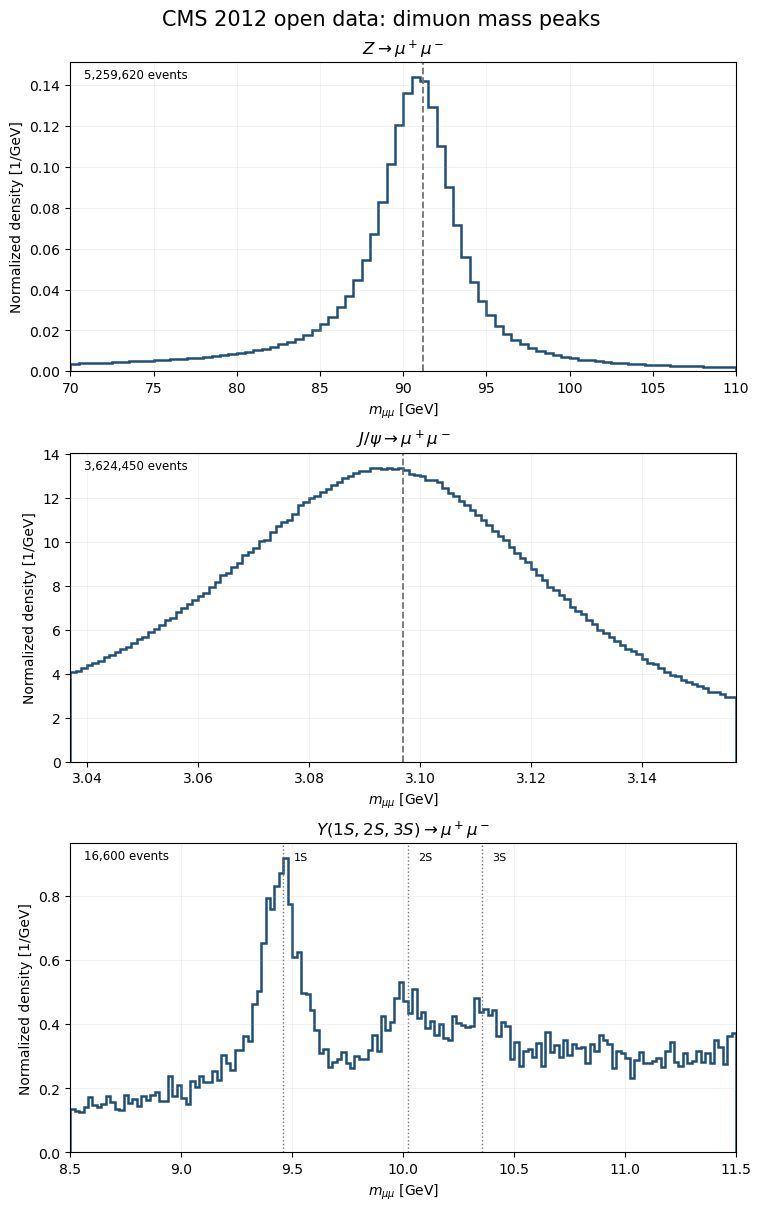

Saved: C:\Users\AhrixMarin\Desktop\otus\scaffold\figures\cms_data_3x1.png


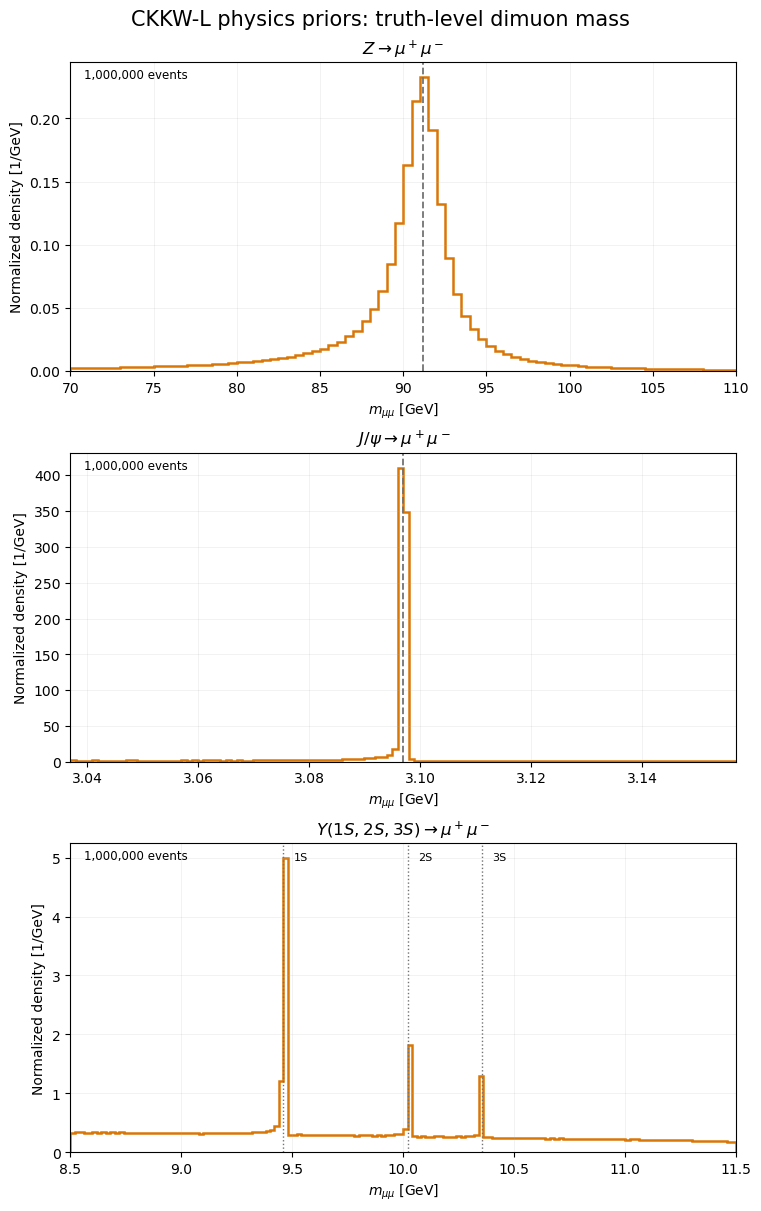

Saved: C:\Users\AhrixMarin\Desktop\otus\scaffold\figures\physics_priors_3x1.png


In [7]:
def plot_vertical(axs, mass_map, data_type):
    for ax, (region, info) in zip(axs, RESONANCES.items()):
        masses = mass_map[region]
        bins = np.linspace(info["mass_min_gev"], info["mass_max_gev"], info["n_bins"] + 1)
        counts, edges = np.histogram(masses, bins=bins)
        bin_width = edges[1] - edges[0]
        density = counts / max(float(counts.sum()), 1.0) / bin_width

        color = {"cms": "#1f4e79", "prior": "#d97706"}[data_type]
        ax.stairs(density, edges, color=color, linewidth=1.8)

        # Optional reference resonance mass(es).
        if region == "y":
            # Y(1S), Y(2S), Y(3S)
            for mass, label in zip((9.4603, 10.0233, 10.3552), ("1S", "2S", "3S")):
                ax.axvline(mass, color="0.45", linestyle=":", linewidth=1.0)
                ax.text(
                    mass + 0.015 * (info["mass_max_gev"] - info["mass_min_gev"]),
                    0.97,
                    label,
                    transform=ax.get_xaxis_transform(),
                    va="top",
                    fontsize=8,
                )
        else:
            ax.axvline(
                info["reference_mass_gev"],
                color="0.45",
                linestyle="--",
                linewidth=1.3,
            )

        ax.set_xlim(info["mass_min_gev"], info["mass_max_gev"])
        ax.set_xlabel(r"$m_{\mu\mu}$ [GeV]")
        ax.set_ylabel("Normalized density [1/GeV]")
        ax.set_title(info["latex"])
        ax.text(
            0.02,
            0.98,
            f"{len(masses):,} events",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8.5,
        )
        ax.grid(alpha=0.18, linewidth=0.6)


# Figure 1: CMS data, vertical 3x1.
fig_cms, axs_cms = plt.subplots(3, 1, figsize=(7.5, 12), constrained_layout=True)
plot_vertical(axs_cms, CMS_MASSES, data_type="cms")
fig_cms.suptitle("CMS 2012 open data: dimuon mass peaks", fontsize=15)
cms_path = FIG_DIR / "cms_data_3x1.png"
fig_cms.savefig(cms_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", cms_path.resolve())

# Figure 2: CKKW-L physics priors, vertical 3x1.
fig_prior, axs_prior = plt.subplots(3, 1, figsize=(7.5, 12), constrained_layout=True)
plot_vertical(axs_prior, PRIOR_MASSES, data_type="prior")
fig_prior.suptitle("CKKW-L physics priors: truth-level dimuon mass", fontsize=15)
prior_path = FIG_DIR / "physics_priors_3x1.png"
fig_prior.savefig(prior_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", prior_path.resolve())